# 21. The Plotted Line: Vector Graphics and the Machine's Hand

Every image in this book so far has been a grid of pixels; today an image becomes a set of *instructions for a moving pen*. We meet vector graphics (Vektorgrafik), displace fields of lines with noise and with a painting, hatch tone out of pure strokes, and leave with files a pen plotter could draw in ink.

## Today's destination

Hokusai's great wave, drawn with nothing but seventy horizontal lines. No fills, no grays, no pixels: each line simply rises wherever the print beneath it is dark, and the wave assembles itself out of the disturbance. The picture belongs to a lineage that runs from the plotter drawings of the 1960s to a radio astronomer's 1970 thesis figure that became one of the most famous album covers ever printed, and it comes with a companion file, an SVG, that is not a picture of the drawing but the drawing's *instructions*: hand them to a machine with a pen and it will perform them on paper. By the end of today, every line-based artwork you have made this book becomes plottable.

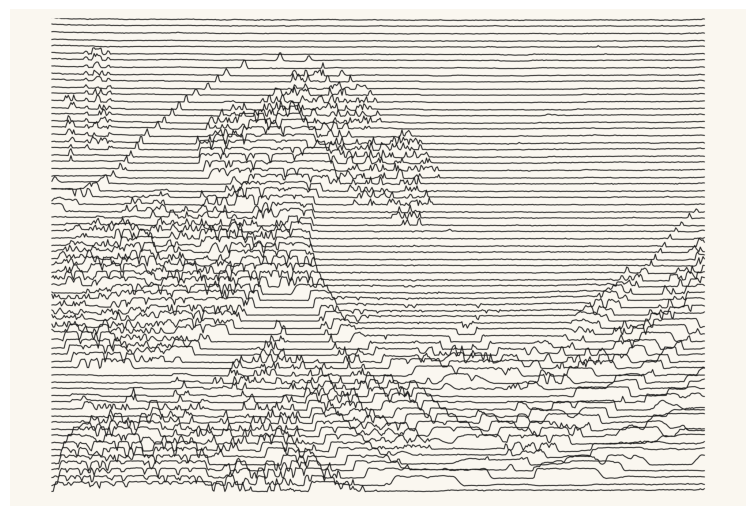

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch21_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(9.5, 6.5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the machine's hand

This chapter gives the book's earliest heroes their machine back. From 1959 **Vera Molnár** generated drawings by following strict rules by hand, a method she called her *machine imaginaire* (you met it in chapter 1); in 1968 she gained access to a computer at a Paris university research lab and became one of the first artists to draw with a computer-driven pen plotter, the imaginary machine made real. Her *(Dés)Ordres* series of the mid-1970s perturbs grids of concentric squares with controlled randomness, its title punning on French *disorders* and *orders*. Three years before her, in September 1965 (the drawing's title records its date), **Frieder Nake** had drawn *Hommage à Paul Klee, 13/9/65 Nr.2* with a Zuse Graphomat Z64 flatbed drawing machine executing his program; a screenprint after the plotter drawing is now in the Victoria and Albert Museum. And **Harold Cohen**, from the late 1960s until his death in 2016, developed the drawing program AARON and built its bodies himself: through the 1970s a wheeled drawing "turtle" and later flatbed machines executed AARON's compositions in real ink before museum audiences.

The lineage has an accidental masterpiece. In 1970 the radio astronomer **Harold D. Craft, Jr.** plotted, for his Cornell dissertation, successive radio pulses of the pulsar CP 1919 recorded at the Arecibo Observatory: a program he wrote stacked the pulse traces one above the next on a computer-driven pen plotter, each line hiding the lines behind its peaks so the stack reads as a mountain range of signal. The band Joy Division found the figure reprinted in *The Cambridge Encyclopaedia of Astronomy* (1977), and Peter Saville inverted it to white on black for the cover of *Unknown Pleasures* (1979). Saville designed the cover, not the plot: the most recognizable album art of its era is, in substance, a scientific pen drawing reproduced whole, and later today we will draw in its dialect.

The pen plotter itself never died; it moved into the living room. Affordable machines, most famously the AxiDraw designed by Evil Mad Scientist Laboratories (its line continues under Bantam Tools, which acquired the company in 2024), sustain a living community of artists who share generative work drawn in ink on paper. Among them is **Jakob Glock**, whose open-source plotter scripts, written in Python for exactly this workflow, prompted this chapter. The community's core insight is aesthetic, not technical: **a plot is a drawing, not a print.** A printer deposits an image all at once; a plotter *performs* it, one continuous stroke at a time, and ink, paper and the pen's pressure all leave their trace. Working under the plotter's discipline (strokes only, no fills, every mark a path) turns out to sharpen composition even on screen, and chapter 14's concentric-ring variant was already obeying it. Every line-based chapter of this book was secretly plottable all along; today we make that explicit.

## Raster and vector

A **raster** image (every image in this book so far) is a grid of pixel colors: enlarge it and the squares show. A **vector** image stores the *geometry* instead: "a line from here to there, this thick". Enlarging a vector image just redraws the same geometry larger, so it has no resolution at all. The web's standard vector format is **SVG** (Scalable Vector Graphics), an XML text format that became a W3C Recommendation in September 2001, and matplotlib can save it as easily as PNG: the same `savefig` call with a different filename ending. Watch both formats meet a magnifying glass:

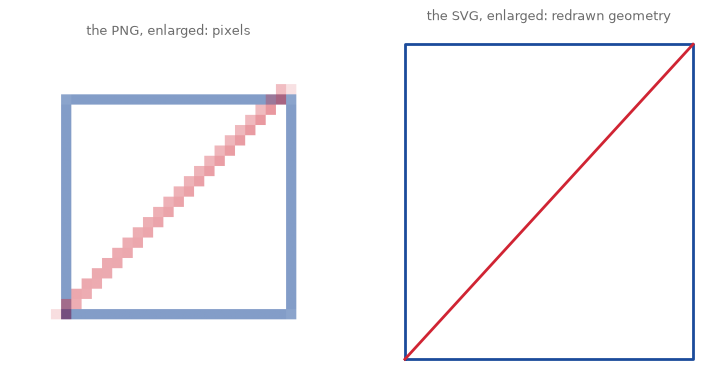

In [2]:
# the same little drawing as pixels and as geometry
import numpy as np

plt.rcParams["svg.hashsalt"] = "agap"     # stable internal ids: re-runs match
fig_tiny, ax = plt.subplots(figsize=(1.2, 1.2))
ax.plot([0.1, 0.9, 0.9, 0.1, 0.1], [0.1, 0.1, 0.9, 0.9, 0.1], color="#1B4B9B")
ax.plot([0.1, 0.9], [0.1, 0.9], color="#D02433")
ax.axis("off")
fig_tiny.savefig("../assets/outputs/ch21_square.png", dpi=26)
fig_tiny.savefig("../assets/outputs/ch21_square.svg")
plt.close(fig_tiny)

from PIL import Image
pixels = np.asarray(Image.open("../assets/outputs/ch21_square.png")) / 255
big = np.kron(pixels[..., :3], np.ones((12, 12, 1)))   # chapter 9's enlarger

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(big)
axes[0].set_title("the PNG, enlarged: pixels", fontsize=9, color="#6B6B6B")
axes[1].plot([0.1, 0.9, 0.9, 0.1, 0.1], [0.1, 0.1, 0.9, 0.9, 0.1],
             color="#1B4B9B", linewidth=2)
axes[1].plot([0.1, 0.9], [0.1, 0.9], color="#D02433", linewidth=2)
axes[1].set_title("the SVG, enlarged: redrawn geometry", fontsize=9,
                  color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

In [3]:
# an SVG is text: open the file and read the drawing itself
svg_text = open("../assets/outputs/ch21_square.svg").read()
print(f"the file is {len(svg_text)} characters of plain text; here is one path:")
stroke_at = svg_text.find("line2d")            # .find locates a substring
start = svg_text.find("<path", stroke_at)      # the first PEN path, not the page fill
print(svg_text[start:start + 380])             # chapter 0's slicing, on a file

the file is 1660 characters of plain text; here is one path:
<path d="M 13.843636 73.872 
L 74.716364 73.872 
L 74.716364 13.392 
L 13.843636 13.392 
L 13.843636 73.872 
" clip-path="url(#p1818de6cc3)" style="fill: none; stroke: #1b4b9b; stroke-width: 1.5; stroke-linecap: square"/>
   </g>
   <g id="line2d_2">
    <path d="M 13.843636 73.872 
L 74.716364 13.392 
" clip-path="url(#p1818de6cc3)" style="fill: none; stroke: #d02433; stroke-w


There is the drawing, spelled out: `d="M ... L ... L ..."` reads *move to this point, line to that one, line to the next*, which is precisely a list of pen movements. (The flood of decimals is matplotlib being cautious; a hand-written SVG can be ten short lines.) This textuality is the deep link to everything the book has done: an SVG is to a drawing what chapter 6's L-system string was to a plant, instructions rather than results.

**Try it.** Open `ch21_square.svg` from `assets/outputs/` in a text editor, change one `L` coordinate by 20, save, and drag the file into a browser: you have just edited a drawing by editing its instructions.

One catch decides what can be plotted at all. When matplotlib saves SVG, line art (`plot`, `LineCollection`, unfilled patches) stays vector, but **`imshow` embeds a bitmap**: a pixel image travels along inside the file as freight, and no pen can draw it. So the plottable chapters are the line-based ones: chapter 1's walks, chapter 3's rosettes, chapter 6's plants, chapter 8's flow trails, chapter 14's ring variant, chapter 15's long exposure, chapter 18's biomorphs. The pixel chapters (fractals, automata, everything `imshow`) can visit paper only through a translation such as hatching, which we build below.

**The plottable discipline**, in three rules. Strokes only: a pen has no "fill", so a solid area must be woven from strokes (hatching). One pen, one width: thickness on paper comes from the physical pen, not a parameter. Economy: every centimeter of line is seconds of machine time and ink laid down, so pen travel is a *budget*, and composing under it is a pleasure of the form.

## The ridge field

Our first plot speaks Craft's dialect directly: a stack of horizontal polylines, each displaced upward by a signal, each hiding whatever runs behind its peaks. The signal is chapter 8's opensimplex noise in two octaves: a broad swell, sharpened by a small power so peaks stand out of calm plains, plus fine roughness scaled by the swell's strength (quietest where the swell dies away). An **envelope** fades the displacement toward the left and right margins, which is what gives such plots their mountain-range-on-a-page look. The hiding is one line of numpy: keep a running *skyline* of the highest ink so far, and let each farther line show only where it rises above it (`np.where` with `np.nan` gaps, chapter 8's broken-polyline trick).

In [4]:
# tools for the plotted half of the chapter
import sys
sys.path.append("..")
from agap.helpers import PAPER, save_artwork
import opensimplex

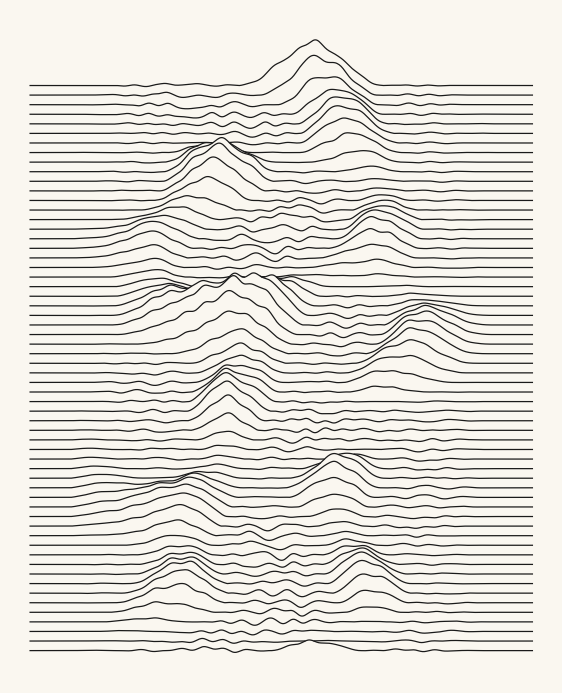

In [5]:
# the ridge field: stacked, displaced, hidden-line-removed
def ridge_field(seed, n_lines=60, amplitude=18, spacing=1.6, figsize=7):
    opensimplex.seed(seed)
    x = np.linspace(0, 100, 500)
    envelope = np.clip(1 - ((x - 50) / 42)**2, 0, 1)**1.5
    fig, ax = plt.subplots(figsize=(figsize, figsize * 1.25))
    fig.patch.set_facecolor(PAPER)
    ax.set_facecolor(PAPER)
    skyline = np.full(len(x), -1e9)          # highest ink so far, per column
    for i in range(n_lines):                 # front (bottom) to back (top)
        # two octaves (chapter 8): 0.045 is the broad swell, 0.35 the roughness
        swell = opensimplex.noise2array(x * 0.045, np.array([i * 0.13]))[0]
        rough = opensimplex.noise2array(x * 0.35, np.array([i * 0.4]))[0]
        y = (i * spacing + envelope * (amplitude * np.maximum(swell, 0)**1.6
                                       + 2.2 * rough * np.abs(swell)))
        ax.plot(x, np.where(y > skyline, y, np.nan), color="#1A1A1A",
                linewidth=0.9)
        skyline = np.maximum(skyline, y)
    ax.set_xlim(-4, 104)
    ax.axis("off")
    plt.show()
    return fig

art_ridge = ridge_field(seed=21)

Every choice here is a plotter choice: one ink, one width, and the drama carried entirely by *where lines refuse to be straight*. The hiding matters more than it seems; comment out the `skyline` update at home and the stack collapses into spaghetti, because overlapping strokes no longer imply depth.

**Try it.** Change the seed for new mountains. Then raise `amplitude` to 35: the peaks start swallowing whole lines, and somewhere past that the page tips from landscape into pure interference.

## The image as displacement

The ridge field displaced its lines with noise. Displace them with a *picture* instead and the picture reappears, performed by the lines: exactly what Craft's plot did (radio intensity displacing each trace) and what we now do to Hokusai. We load the print small and in grayscale (chapter 12's luminance move), and each of seventy horizontal lines rises in proportion to the darkness directly beneath it.

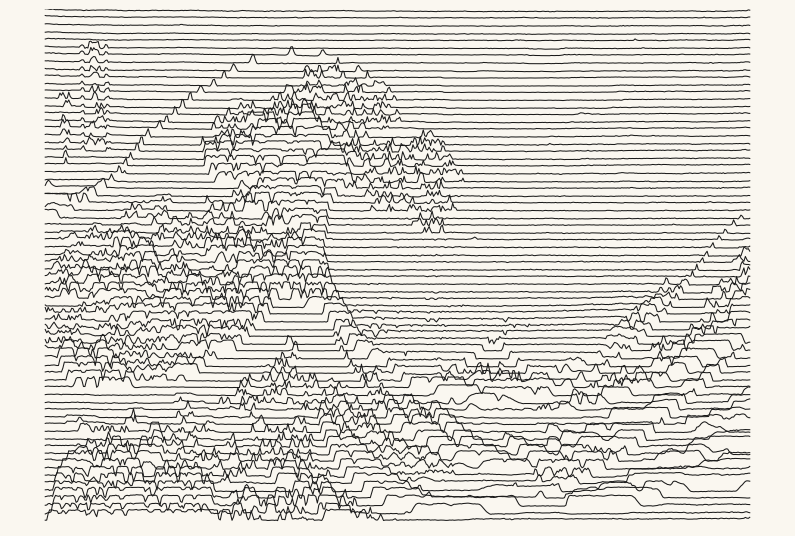

In [6]:
# Hokusai performed by seventy horizontal lines
from PIL import Image

def displaced_lines(darkness, n_lines=70, amplitude=9, figsize=10):
    height, width = darkness.shape
    fig, ax = plt.subplots(figsize=(figsize, figsize * height / width))
    fig.patch.set_facecolor(PAPER)
    ax.set_facecolor(PAPER)
    xs = np.arange(width)
    for i in range(n_lines):
        row = int((i + 0.5) * height / n_lines)
        ax.plot(xs, row - darkness[row] * amplitude, color="#1A1A1A",
                linewidth=0.75)
    ax.set_ylim(height, 0)                   # image convention: y downward
    ax.axis("off")
    plt.show()
    return fig

wave_image = Image.open("../assets/images/hokusai_wave.jpg")
wave_w = 480
wave_h = int(wave_image.height * wave_w / wave_image.width)
wave_dark = 1 - np.asarray(wave_image.convert("L")
                           .resize((wave_w, wave_h))) / 255
art_wave = displaced_lines(wave_dark)

**Look and compare.** The wave, the boats, even Fuji assemble out of pure horizontal strokes; where the print is pale the lines lie flat and the paper does the resting. Squint and it is a picture; look close and it is only disturbance. Which regions survive the translation best, and what do they have in common?

## Hatching: tone from strokes

A pen cannot fill, so plotter artists weave tone from parallel strokes: **hatching** (Schraffur), the same craft engravers used centuries before machines. Two ingredients. The *direction* of a hatch family comes from chapter 3's trigonometry: a unit vector $(\cos\theta, \sin\theta)$ along the strokes and its perpendicular for stepping between them. The *where* is a True/False mask, and we clip each long stroke against it by sampling points along the line and hiding the points that fall outside (`np.nan` again). First, one hatch family through a simple mask:

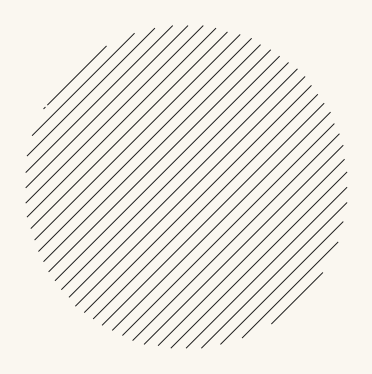

In [7]:
# hatch a mask with one family of parallel strokes at an angle
def hatch_mask(ax, mask, angle_degrees, spacing, linewidth=0.7):
    height, width = mask.shape
    theta = np.radians(angle_degrees)
    along = np.array([np.cos(theta), np.sin(theta)])     # chapter 3's circle trig
    across = np.array([-np.sin(theta), np.cos(theta)])
    reach = np.hypot(width, height)
    center = np.array([width / 2, height / 2])
    t = np.arange(-reach, reach, 1.0)[:, None]   # a column: chapter 12's axis-adding trick
    for offset in np.arange(-reach, reach, spacing):
        points = center + offset * across + t * along
        px, py = points[:, 0], points[:, 1]
        on_canvas = (px >= 0) & (px < width) & (py >= 0) & (py < height)
        keep = np.zeros(len(points), bool)
        keep[on_canvas] = mask[py[on_canvas].astype(int), px[on_canvas].astype(int)]
        ax.plot(np.where(keep, px, np.nan), np.where(keep, py, np.nan),
                color="#1A1A1A", linewidth=linewidth)

grid_x, grid_y = np.meshgrid(np.arange(240), np.arange(240))   # chapter 7's grid
disc = np.hypot(grid_x - 120, grid_y - 120) < 90
fig, ax = plt.subplots(figsize=(4.6, 4.6))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)
hatch_mask(ax, disc, angle_degrees=45, spacing=6)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

A filled circle that contains no fill: only strokes and their refusal to cross a boundary. Now the engraver's full trick, **crosshatching by tone**: slice the wave's darkness into bands (chapter 12's two-tone thinking, extended to four), and give each darker band one more hatch family at a new angle. Ink accumulates exactly where the print is dark, and tone emerges from pure geometry.

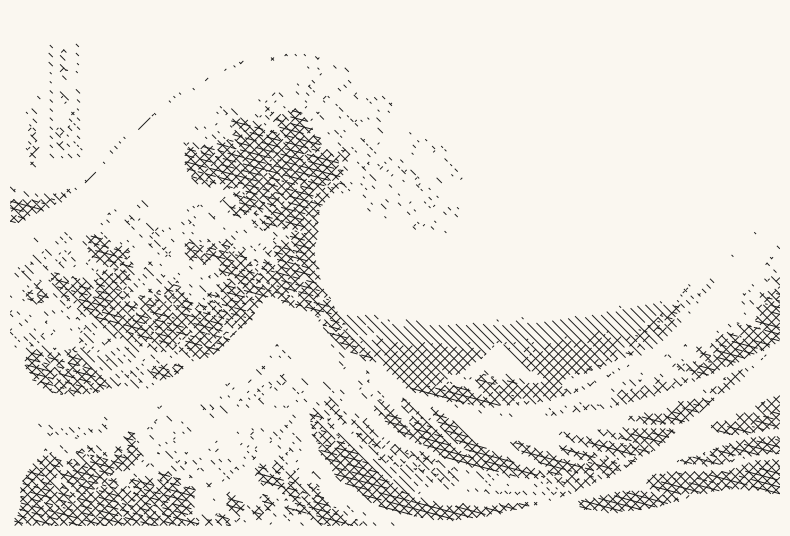

In [8]:
# crosshatch the wave: one more hatch family per band of darkness
bands = [0.25, 0.45, 0.65, 0.85]         # darkness thresholds, light to dark
angles = [45, -45, 15, 75]               # a new stroke direction per band

fig, ax = plt.subplots(figsize=(10, 10 * wave_h / wave_w))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)
for level, angle in zip(bands, angles):
    hatch_mask(ax, wave_dark > level, angle, spacing=4)
ax.set_xlim(0, wave_w)
ax.set_ylim(wave_h, 0)
ax.set_aspect("equal")
ax.axis("off")
plt.show()
art_hatch = fig

**Try it.** Swap the four angles for `[0, 90, 45, -45]` and the drawing turns woven, almost textile; then set all four to `45` and watch the tone *vanish*: the darker bands hide inside the lightest band's identical strokes and the drawing flattens to a single hatching, which is exactly why the engraver's angles must differ. The angle set is a *voice*: engravers were recognized by theirs.

## Playground: the arc garden

One more plottable system, this time pure ornament: fields of concentric arcs (chapter 3's circle trigonometry once more, drawn as open strokes). Each center grows rings that keep a random start and span, so the garden reads as calligraphy from some circular alphabet.

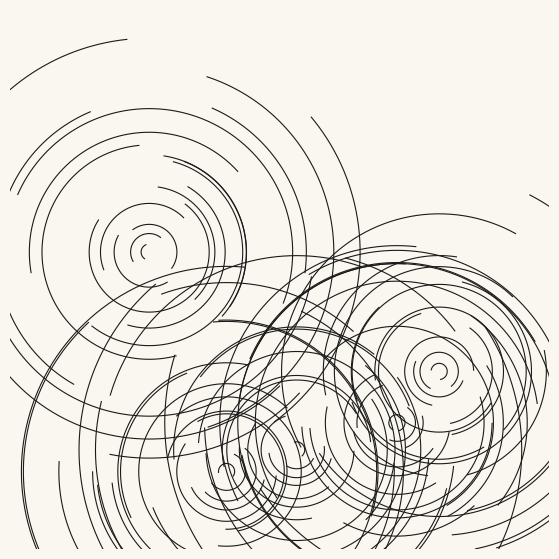

In [9]:
# the arc garden: concentric open arcs from a handful of centers
def arc_garden(seed, n_centers=5, rings=22, figsize=7):
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(figsize, figsize))
    fig.patch.set_facecolor(PAPER)
    ax.set_facecolor(PAPER)
    for center in range(n_centers):
        cx, cy = rng.uniform(10, 90, size=2)
        for ring in range(rings):
            radius = 1.5 + ring * rng.uniform(1.6, 2.1)
            start = rng.uniform(0, 2 * np.pi)
            span = rng.uniform(1.2, 5.6) * (1 - 0.6 * ring / rings)
            angle = np.linspace(start, start + span, 240)
            ax.plot(cx + radius * np.cos(angle), cy + radius * np.sin(angle),
                    color="#1A1A1A", linewidth=0.8)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

art_arcs = arc_garden(seed=9)

**Try it.** More centers crowd the page toward texture; two centers make a conversation. And notice what the shrinking `span` does: outer rings dwindle to gestures, so each system fades at its edge instead of stopping.

## The fern, one last time

For the export we add one veteran: chapter 6's fern, condensed exactly as chapter 20 condensed it to make the fern sing (chapter 5's honest-reuse pattern, one final performance). It was born plottable, a creature of pure line segments; it only never had its SVG.

In [10]:
# chapter 6, condensed: the L-system engine and the turtle, copied forward
import math

def rewrite(axiom, rules, iterations):
    string = axiom
    for _ in range(iterations):
        next_string = ""
        for symbol in string:
            next_string = next_string + rules.get(symbol, symbol)
        string = next_string
    return string

def interpret(instructions, angle_degrees, step=1.0):
    x, y = 0.0, 0.0
    heading = math.pi / 2
    turn = math.radians(angle_degrees)
    stack, segments = [], []
    for symbol in instructions:
        if symbol == "F":
            x_new = x + step * math.cos(heading)
            y_new = y + step * math.sin(heading)
            segments.append(((x, y), (x_new, y_new)))
            x, y = x_new, y_new
        elif symbol == "+":
            heading = heading + turn
        elif symbol == "-":
            heading = heading - turn
        elif symbol == "[":
            stack.append((x, y, heading))
        elif symbol == "]":
            x, y, heading = stack.pop()
    return segments

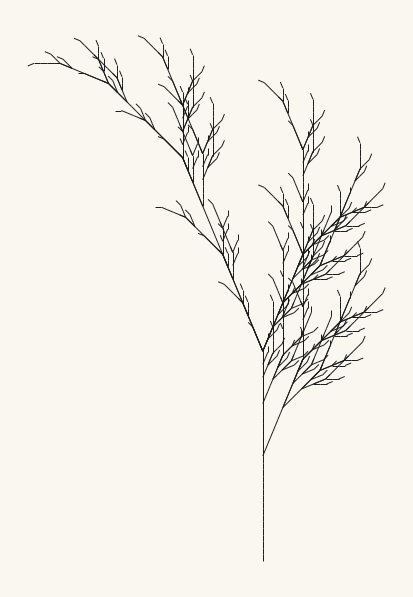

1488 pen strokes


In [11]:
# the fern as strokes on paper (a LineCollection, as in chapter 6)
from matplotlib.collections import LineCollection

fern_rules = {"X": "F-[[X]+X]+F[+FX]-X", "F": "FF"}
fern_segments = interpret(rewrite("X", fern_rules, 5), 22.5)

fig, ax = plt.subplots(figsize=(6, 7.5))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)
ax.add_collection(LineCollection(fern_segments, colors="#1A1A1A",
                                 linewidths=0.7))
ax.autoscale()
ax.set_aspect("equal")
ax.axis("off")
plt.show()
art_fern = fig
print(f"{len(fern_segments)} pen strokes")

## The export pass

Every figure above is geometry, so each can leave as an SVG: same `savefig`, different suffix. The SVGs land in `assets/outputs/` next to the PNGs; open one in a text editor or a browser and it is all `<path>` elements, machine-ready.

In [12]:
# save the drawings as vector files, ready for a plotter's software
for done_fig, name in [(art_ridge, "ridge"), (art_wave, "wavelines"),
                       (art_hatch, "hatch"), (art_arcs, "arcs"),
                       (art_fern, "fern")]:
    svg_path = f"../assets/outputs/ch21_{name}.svg"
    done_fig.savefig(svg_path, facecolor=PAPER)
    print(f"saved: {svg_path}")

saved: ../assets/outputs/ch21_ridge.svg
saved: ../assets/outputs/ch21_wavelines.svg
saved: ../assets/outputs/ch21_hatch.svg
saved: ../assets/outputs/ch21_arcs.svg
saved: ../assets/outputs/ch21_fern.svg


### Ready for the plotter: a checklist

- **Page size:** make the figure the paper's shape from the start (`figsize` in inches; A4 is 8.3 x 11.7).
- **Margins:** keep every stroke well inside the page, 10 mm or more; plotters cannot draw to the edge and clips are ugly in ink.
- **Stroke width:** on paper the *pen* decides; treat `linewidth` as a screen preview only, and draw one test page per pen.
- **One path per polyline:** each `plot` call becomes one `<path>`, and the `np.nan` gaps split a path where the pen should lift. Avoid thousands of tiny separate segments where one polyline would do (pen lifts cost time and registration); the fern above is guilty, 1488 two-point segments, and plotter tools such as vpype merge chains like these before the pen moves.
- **No fills anywhere:** if a region needs tone, hatch it.

Plotter software (the AxiDraw's, and every serious tool since) accepts SVG directly; from here it is pen, paper and patience.

## Export your artwork

Any of today's four systems, your parameters: new mountains, another painting under the lines (the Vermeer performs beautifully), your own angle voice for the crosshatch, a garden of your own arc alphabet. Replace `yourname` and run: you get the print-quality PNG as always, *and* the machine-readable SVG beside it.

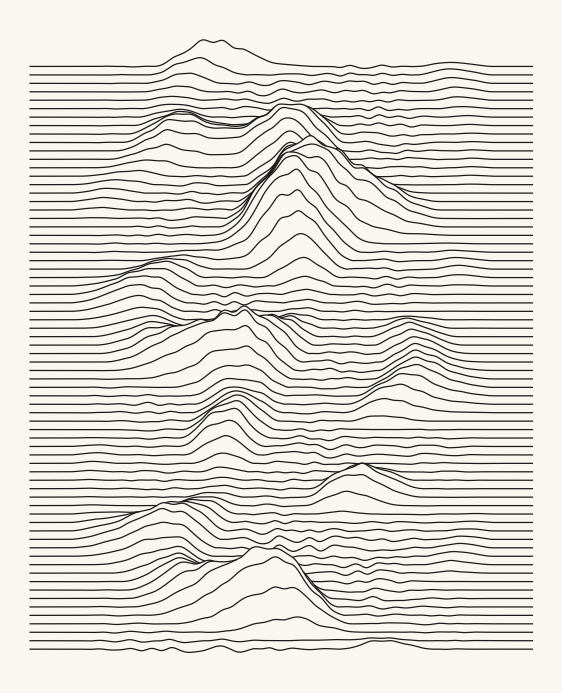

saved: assets/outputs/ch21_yourname.png
saved: ../assets/outputs/ch21_yourname.svg


In [13]:
# save YOUR artwork, twice: pixels for the gallery, geometry for the pen
my_artwork = ridge_field(seed=2027, n_lines=70, amplitude=22)
saved_path = save_artwork(my_artwork, "yourname", chapter=21)
my_artwork.savefig("../assets/outputs/ch21_yourname.svg", facecolor=PAPER)
print("saved: ../assets/outputs/ch21_yourname.svg")

## Exercises

**(a) Parameter exploration: the moiré boundary.** In `displaced_lines`, sweep `n_lines` through 30, 70, 150 and `amplitude` through 4, 9, 18. At low counts the wave dissolves into abstraction; at high counts and amplitudes neighboring lines begin to collide and shimmer (moiré). Find the pair where the image is most *present* with the least ink, and note how that budget-consciousness is exactly the plotter's discipline.

**(b) Code modification: rotate the system, then cross it.** First write `displaced_lines_vertical`: vertical lines displaced *horizontally* by the darkness under them (columns instead of rows). Then combine: draw the horizontal family everywhere, and the vertical family only where the print is genuinely dark, so the two directions cross into a luminance-driven crosshatch.

<details><summary>Solution</summary>

```python
def displaced_lines_vertical(darkness, n_lines=70, amplitude=9, ax=None):
    height, width = darkness.shape
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10 * height / width))
        fig.patch.set_facecolor(PAPER)
        ax.set_facecolor(PAPER)
    ys = np.arange(height)
    for i in range(n_lines):
        column = int((i + 0.5) * width / n_lines)
        ax.plot(column - darkness[:, column] * amplitude, ys,
                color="#1A1A1A", linewidth=0.75)
    ax.set_ylim(height, 0)
    ax.axis("off")
    return ax.figure

# the crossing: horizontals everywhere, verticals only in the dark
fig, ax = plt.subplots(figsize=(10, 10 * wave_h / wave_w))
fig.patch.set_facecolor(PAPER)
ax.set_facecolor(PAPER)
xs = np.arange(wave_w)
for i in range(70):
    row = int((i + 0.5) * wave_h / 70)
    ax.plot(xs, row - wave_dark[row] * 9, color="#1A1A1A", linewidth=0.7)
ys = np.arange(wave_h)
for i in range(70):
    column = int((i + 0.5) * wave_w / 70)
    deep = np.where(wave_dark[:, column] > 0.45,
                    column - wave_dark[:, column] * 9, np.nan)
    ax.plot(deep, ys, color="#1A1A1A", linewidth=0.7)
ax.set_ylim(wave_h, 0)
ax.axis("off")
plt.show()
```

The verticals arrive only where the print is dark (the `np.nan` trick clips them), so shadow regions get woven while highlights stay airy: displacement carries the drawing, crossing carries the tone.
</details>

**(c) Creative challenge: restage a veteran.** Choose any line-based artwork you made this book (a chapter 1 walk, a chapter 3 rosette, a chapter 8 flow field, a chapter 14 ring pack, a chapter 18 creature) and restage it under the plottable discipline: one ink, strokes only, honest margins, one page. Export the SVG next to the PNG. And if you ever meet a plotter, plot it: the file is ready, and ink on paper is where these drawings were always headed.

## Further reading

- Grant D. Taylor, *When the Machine Made Art: The Troubled History of Computer Art* (Bloomsbury Academic, 2014): the plotter era and its cold reception, told properly.
- *Vera Molnár: 100* (Éditions du Centre Pompidou, 2024): the centenary retrospective catalogue, in French; the plotter drawings in quantity.
- Jen Christiansen, "Pop Culture Pulsar: Origin Story of Joy Division's *Unknown Pleasures* Album Cover" (Scientific American blog, 2015, free online): the Craft interview, with the original plots.
- The [MDN SVG documentation](https://developer.mozilla.org/en-US/docs/Web/SVG): the whole format, path syntax included, patiently explained.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: the wave performed by seventy displaced lines. It runs in seconds with *Restart & Run All*.

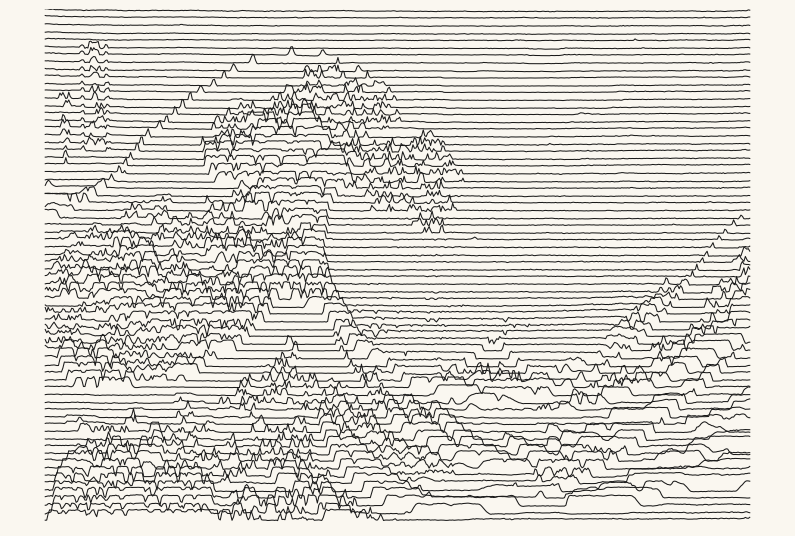

saved: assets/outputs/ch21_showpiece.png
saved: ../assets/outputs/ch21_showpiece.svg


In [14]:
# regenerate this chapter's showpiece: Hokusai as pure displacement
showpiece = displaced_lines(wave_dark, n_lines=70, amplitude=9, figsize=10)
saved_path = save_artwork(showpiece, "showpiece", chapter=21)
showpiece.savefig("../assets/outputs/ch21_showpiece.svg", facecolor=PAPER)
print("saved: ../assets/outputs/ch21_showpiece.svg")